# **1. Load and process data**

### 1.1. Parameters, packages and paths

In [7]:
country = "NGA"
scenario_name = "NGA_sensitivity_2"

In [8]:
from __future__ import annotations

In [9]:
# constants and parameters
from parameters import *

# Core dependencies for tabular, spatial, and raster work
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt 
import numpy as np
import rasterio
from rasterio.mask import mask as raster_mask
import shapely
from shapely.geometry import Point, box, shape, LineString
from skimage.graph import MCP_Geometric
from pyproj import Geod, CRS
from onstove.layer import VectorLayer, RasterLayer
from shapely.ops import nearest_points
from scipy.optimize import linprog
from openpyxl import Workbook
import warnings

import contextlib
import heapq
import io
import json
import math
import os
import shutil
import sqlite3
import time
from pathlib import Path
from typing import Dict, List, Sequence, Tuple, Optional
import rioxarray
import xarray as xr
from onstove import OnStove
from rasterio.features import geometry_mask, shapes
from rasterio.transform import rowcol
from rasterio.warp import Resampling, reproject, transform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
import rioxarray
from rasterio.warp import Resampling


from dataclasses import dataclass

# Workspace data folder 
data_dir = Path("dataset")
data_dir.mkdir(exist_ok=True)

import function_tools as tool
import function_costs as cost
import function_allocation as alloc
import function_process as process

# Default gpkg and layer names
DEFAULT_GPKG = data_dir / "default.gpkg" #TODO ricorda di modificare
DEFAULT_LAYERS = {
    'refineries': 'refineries',
    'ports': 'ports',
    'gas_plants': 'gas_plants',
    'primary_storage': 'primary_storage',
    'border_points': 'border_points',
}

# Define mask layer
mask_layer = gpd.read_file(data_dir / "mask_layer_f.gpkg") # TODO: sistema la questione mask layer - fai in modo che anche se non c'è la friction nel posto dove è collocato un punto, non ce problema)
# TODO crea pre aggiustamento di tutti i CRS

#settings
cost_risk_aversion = False # TODO remember to modify
price_variation = 2.0 # TODO remember to modify 

### 1.2. Data loading

##### 1.2.1. Part 1

In [10]:
# Initialize points dictionary to store processed facility layers
points = {}

# Load facility layers (user files first, otherwise defaults)
try:
    for p_type in ['refineries', 'ports', 'gas_plants', 'primary_storage', 'border_points']:
        points[p_type] = tool.load_or_use_default(p_type, DEFAULT_GPKG, DEFAULT_LAYERS[p_type], mask_layer, data_dir)
    print("\n")
          
    # Read multiband rasters and use average over mask_layer as actual values
    national_shares = tool.load_raster_means(data_dir / "national_shares.tif", ['ports', 'refineries', 'gas_plants', 'border_points'], mask_layer)
    lpg_import_cost = tool.load_raster_means(data_dir / "lpg_import_cost.tif", ['import_land', 'import_sea'], mask_layer)

    # Calculate the mean of lpg_household_shares.tif over the masked area
    lpg_household_shares_df = tool.load_raster_means(data_dir / "lpg_household_shares.tif", ['percentage_house'], mask_layer)

    print("\nNational shares (mean over masked area, raw):")
    print(national_shares)

    # Redistribute shares below 1% across the remaining supply modes
    national_shares = process.redistribute_small_national_shares(national_shares, min_share_pct=1.0)

    print("\nNational shares (after redistribution of modes < 1%):")
    print(national_shares)

    print("\nLPG import costs (mean over masked area):")
    print(lpg_import_cost)

    # Load defaults once
    default_data = {name: gpd.read_file(DEFAULT_GPKG, layer=layer_name) for name, layer_name in DEFAULT_LAYERS.items()}

except (FileNotFoundError, ValueError) as e:
    print(f"Data loading error: {e}")

refineries: loaded from default.gpkg/refineries | inside=4, moved_inside_mask=0, dropped_far=18
ports: loaded from default.gpkg/ports | inside=11, moved_inside_mask=2, dropped_far=104
gas_plants: loaded from default.gpkg/gas_plants | inside=5, moved_inside_mask=2, dropped_far=6
primary_storage: loaded from default.gpkg/primary_storage | inside=19, moved_inside_mask=1, dropped_far=127
border_points: loaded from default.gpkg/border_points | inside=3, moved_inside_mask=3, dropped_far=179




d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_ports layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_refineries layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_gas_plants layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_border_points layer do not hav


National shares (mean over masked area, raw):
                       1
ports          50.664368
refineries      0.785131
gas_plants     48.199532
border_points   0.350969

National shares (after redistribution of modes < 1%):
                       1
ports          51.246581
refineries      0.000000
gas_plants     48.753419
border_points   0.000000

LPG import costs (mean over masked area):
                    1
import_land  0.094122
import_sea   0.019422


##### 1.2.2. Part 2

In [ ]:
MODEL_PICKLE_PATH          = data_dir / "model_inputs_mattia.pkl"
SCENARIO_CSV_PATH          = data_dir / "soc_specs.csv"
INCOME_RASTER_PATH         = data_dir / "income.tif"
VEHICLE_POSSIBILITY_PATH   = data_dir / "vehicle_possibility.tif"
VEHICLES_SHARE_PATH        = data_dir / "vehicles_allocation_share.tif"
WALK_SHARE_PATH            = data_dir / "walk_allocation_share.tif"
VEHICLES_N_PATH            = data_dir / "vehicles_allocation_n_effettivo.tif"
POPULATION_RASTER_PATH     = data_dir / "Population.tif"
URBAN_RASTER_PATH          = data_dir / "Urban.tif"
COUNTRY_BOUNDARIES_PATH    = data_dir / "Country_boundaries.geojson"
HUFF_PIXEL_RASTER_PATH     = data_dir / "huff_preferred_distributor_per_pixel.tif"
LPG_USE_SHARE_PATH         = data_dir / "lpg_use_share.tif"
END_USER_PRICE_PATH        = data_dir / f"end_user_price_{scenario_name}.tif"
SUPPLY_CHAIN_LAYER_PATH    = data_dir / f"supply_chain_layer_{scenario_name}.gpkg"
FRICTION_MOTO              = data_dir / "friction_moto.tif"   
FRICTION_WALK              = data_dir / "friction_walk.tif"
FULL_CHAIN_GPKG_PATH       = data_dir / "full_lpg_chain_nig_3857.gpkg"  

# TODO applicare mask layer a tutti i raster
# TODO uniformare CRS
# TODO rimuovere duplicati nei path

SELL_LAYER = "resell_and_filling" #filling can serve clients # TODO assicurarsi che se l'utente vuole inserire i reseller/filling la cosa sia il piu semplice possibile (esempio: creazione degli id avvenga internamente al processo di caricamento)
FILLING_LAYER = "filling"
ID_COL = "id_res&fil"
ATTRACTIVENESS_COL = "attractiveness"


points['reseller_points'] = tool.load_or_use_default(
    gpkg_name="sell_point",          # dummy name – will not exist, fallback used
    default_gpkg_path=DEFAULT_GPKG,
    default_layer_name=SELL_LAYER,      # "resell_and_filling"
    mask_gdf=mask_layer,
    data_dir=data_dir,
    near_km=0.1,
)                                  

# Load filling points similarly
points['filling_points'] = tool.load_or_use_default(
    gpkg_name="filling_points",
    default_gpkg_path=DEFAULT_GPKG,
    default_layer_name=FILLING_LAYER,     # "filling"
    mask_gdf=mask_layer,
    data_dir=data_dir,
    near_km=0.1,
)


origins = points['reseller_points'].copy()
# Ensure attractiveness column exists (if not, add default)
#TODO: metilo quando carica utente
if ATTRACTIVENESS_COL not in origins.columns:
    origins[ATTRACTIVENESS_COL] = 1.0


sell_point: loaded from default.gpkg/resell_and_filling | inside=2784, moved_inside_mask=2, dropped_far=10890
filling_points: loaded from default.gpkg/filling | inside=375, moved_inside_mask=0, dropped_far=1929


### 1.3. Data processing

##### 1.3.1. Part 1

In [12]:
# Apply processing for each facility type
lpg_price_raster = data_dir / 'fob_per_kg.tif'   # TODO CEPII? dovrebbe essere apposto

points['refineries'] = process.refineries(points['refineries'], default_data['refineries'], lpg_price_raster_path=lpg_price_raster, mask_layer=mask_layer)
points['primary_storage'] = process.primary_storage(points['primary_storage'], default_data['primary_storage'], lpg_price_raster_path=lpg_price_raster)
# for ports, there is the option to use as cost_source some historic data for that port:
##    - set use_historic_data to true
##    - set historic_data_col to the name of the column in default_data['ports'] that contains the historic data to use as cost_source
##      (default.gpkg contains the columns source_price_xxxx_yyy, where xxxx is the year and yyy is either 'imp' or 'exp')
points['ports'] = process.ports(points['ports'], default_data['ports'], points['primary_storage'], lpg_price_raster_path=lpg_price_raster, mask_layer=mask_layer)
points['gas_plants'] = process.gas_plants(points['gas_plants'], default_data['gas_plants'], lpg_price_raster_path=lpg_price_raster, mask_layer=mask_layer)
points['border_points'] = process.border_points(points['border_points'], default_data['border_points'], national_shares, lpg_price_raster_path=lpg_price_raster, country=country, mask_layer=mask_layer)

##### 1.3.2. Part 2

In [13]:
# 1) Generate the base Income Raster
process.generate_income_raster(
    model_pickle_path=os.path.normpath(str(MODEL_PICKLE_PATH)),
    scenario_csv_path=os.path.normpath(str(SCENARIO_CSV_PATH)),
    output_directory=str(data_dir),

    output_raster_name="income"
)

# 2) Normalize and map it to Vehicle Possibility
process.generate_vehicle_possibility(
    input_path=str(INCOME_RASTER_PATH),
    output_vehicle_path=str(VEHICLE_POSSIBILITY_PATH),
    urban_raster_path=str(URBAN_RASTER_PATH),
    population_raster_path=str(POPULATION_RASTER_PATH),
)

# 3) Target Alpha Allocation (Car, Walk, Users parameters)
process.allocate_vehicles(
    vehicle_possibility_path=str(VEHICLE_POSSIBILITY_PATH),
    population_path=str(POPULATION_RASTER_PATH),
    urban_raster_path=str(URBAN_RASTER_PATH),
    output_share_car_path=str(VEHICLES_SHARE_PATH),
    output_share_walk_path=str(WALK_SHARE_PATH),
    output_cars_path=str(VEHICLES_N_PATH)
)

[AWE Recovery] Input Pixels: 560,635, Recovered Pixels: 563,852
Calibration complete: Final Alpha=0.9248
Allocated Vehicles: 11,600,000 (Target: 11,600,000)


In [14]:
tool.export_gpkg(points, data_dir, country)

# **2. Allocations**

In [15]:
if points['primary_storage'].geometry.is_empty.all():
    storage = False
else:
    storage = True

### 2.1. Supply → Storage

##### 2.1.1. Assign facilities

In [16]:
# Precompute friction surface once to save memory and processing time
surface_data = alloc.build_surface(FRICTION_MOTO)

In [17]:
if storage:  # Assign each supply point to the nearest primary storage point based on the friction surface
    for supply in ['refineries', 'ports', 'gas_plants', 'border_points']:
        points[supply] = alloc.assign_nearest(
            layer1=points['primary_storage'],
            layer2=points[supply],
            layer1_name='primary_storage',
            surface_data=surface_data,
            layer1_id_col='id_supply'
        )

tool.export_gpkg(points, data_dir, country)

##### 2.1.2. Calculate percentages
for ports, among the various options on which base the percentage calculation, consider these three:
 - LPG_capacity: allocate based on capacity of storage sites nearby
 - LPG_import_xxxx: allocate based on import volumes of year xxxx, with xxxx = 2023, 2024, 2025 available in default.gpkg
 - [NIGERIA ONLY] percentage_CITAC: allocate based on the percentage of total imports for that port over the total imports of all ports of Nigeria, as reported by CITAC

In [18]:
# Calculate supply percentages for each supply point, then aggregate to storage level

step = "supply"

first_step, layers_by_category = alloc.calculate_percentages(step, 
    refineries_gdf = points["refineries"],
        
    ports_gdf = points["ports"], ports_cols = ['percentage_CITAC'], 
    gas_plants_gdf = points["gas_plants"], 
    border_points_gdf = points["border_points"], border_points_cols=f"percentage_importer",
    nat_shares_df = national_shares)

points = {   # TODO si puo direttamente assegnare points come risultato della funzione calculate_percentages?
    "refineries": layers_by_category["refineries"],
    "ports": layers_by_category["ports"],
    "gas_plants": layers_by_category["gas_plants"],
    "primary_storage": points["primary_storage"],
    "border_points": layers_by_category["border_points"],
    "reseller_points": points["reseller_points"],
    "filling_points": points["filling_points"]
}

if storage:
    # Aggregate supply percentages to storage level
    points["primary_storage"] = alloc.aggregate_to_storage(step,
        primary_storage_gdf=points["primary_storage"],
        refineries_gdf=points["refineries"],
        ports_gdf=points["ports"],
        gas_plants_gdf=points["gas_plants"],
        border_points_gdf=points["border_points"]
    )

tool.export_gpkg(points, data_dir, country)

Check: 24 sources calculated | Total share: 100.00%
✓ Supply aggregated to 20 storage facilities | Total supply: 1.0000


### 2.2. Filling → Reseller → Households

##### 2.2.1. Assign facilities

In [19]:
# --- Reproject friction_moto to match population.tif (reference grid) ---
# population.tif is the authority for CRS, resolution, and extent.

pop_ref = rioxarray.open_rasterio(str(POPULATION_RASTER_PATH))
moto_raw = rioxarray.open_rasterio(str(FRICTION_MOTO))
moto_reprojected = moto_raw.rio.reproject_match(
    pop_ref,
    resampling=Resampling.nearest  
)
# Save to a temporary aligned path (used only for this run)
FRICTION_MOTO_ALIGNED = data_dir / "friction_moto_aligned.tif"
moto_reprojected.rio.to_raster(str(FRICTION_MOTO_ALIGNED), compress="DEFLATE")
pop_ref.close()
moto_raw.close()
moto_reprojected.close()
print(f"friction_moto reprojected to match population.tif → {FRICTION_MOTO_ALIGNED}")
FRICTION_MOTO = FRICTION_MOTO_ALIGNED  # Use the aligned version for the rest of the process
FRICTION_MOTO = FRICTION_MOTO_ALIGNED


alloc.assign_best(         # anziché usare il layer "reseller and filling" fai in modo che questo layer non esista piu!
    origins=origins,
    origin_id_col=ID_COL,
    destinations=None,
    layer1_name="reseller_walk",
    friction_path=FRICTION_WALK,
    huff=True,
    attractiveness_col=ATTRACTIVENESS_COL,
    output_raster_path=data_dir / "huff_walk.tif",
    pop_mask=str(POPULATION_RASTER_PATH),
)

alloc.assign_best(
    origins=origins,
    origin_id_col=ID_COL,
    destinations=None,
    layer1_name="reseller_moto",
    friction_path=FRICTION_MOTO,
    huff=True,
    attractiveness_col=ATTRACTIVENESS_COL,
    output_raster_path=data_dir / "huff_moto.tif",
    pop_mask=str(POPULATION_RASTER_PATH),
)

# 2. Join the data into the 8-band master file needed by the cost functions
tool.stack_huff_rasters(
    output_path=HUFF_PIXEL_RASTER_PATH,
    car_share_path=VEHICLES_SHARE_PATH,
    walk_share_path=WALK_SHARE_PATH,
    huff_walk_path=data_dir / "huff_walk.tif",
    huff_moto_path=data_dir / "huff_moto.tif"
)

# 3. Filling → reseller (nearest, no Huff)
print("\n=== Filling assignment ===")
filling = points['filling_points']
resell = points['reseller_points']

points['reseller_points'] = alloc.assign_best(
    origins=filling,
    origin_id_col=ID_COL,
    destinations=resell,
    layer1_name="filling_points",
    friction_path=FRICTION_MOTO,
    huff=False,
)

tool.export_gpkg(points, data_dir, country)

friction_moto reprojected to match population.tif → dataset\friction_moto_aligned.tif
[reseller_walk] 250,000/563,851 (44.34%) | 31088.4 px/s | ETA 0.2 min
[reseller_walk] 500,000/563,851 (88.68%) | 31741.3 px/s | ETA 0.0 min
[reseller_walk] 563,851/563,851 (100.00%) | 31336.3 px/s | ETA 0.0 min
[reseller_walk-exact] Processing 2,530 resellers...
[reseller_walk-exact] 500/2,530 resellers done (19.8%) | 52.6 res/s | ETA 0.6 min
[reseller_walk-exact] 1,000/2,530 resellers done (39.5%) | 46.0 res/s | ETA 0.6 min
[reseller_walk-exact] 1,500/2,530 resellers done (59.3%) | 39.1 res/s | ETA 0.4 min
[reseller_walk-exact] 2,000/2,530 resellers done (79.1%) | 31.6 res/s | ETA 0.3 min
[reseller_walk-exact] 2,500/2,530 resellers done (98.8%) | 28.7 res/s | ETA 0.0 min
  Skipped pixels: 0/946035 (0.0%) due to distance or time limits.
[reseller_walk-exact] All resellers processed. Assigned pixels recomputed.
[reseller_moto] 250,000/563,482 (44.37%) | 34185.0 px/s | ETA 0.2 min
[reseller_moto] 500,00

##### 2.2.2. Enrich with additional data

In [20]:
filling_for_demand = points['filling_points'].copy()

# Enrich the in-memory layers with client demand calculations directly
points['reseller_points'], points['filling_points'] = alloc.calibrate_demand_and_allocate_clients(
    pixel_pref_path=str(HUFF_PIXEL_RASTER_PATH),
    pop_path=str(POPULATION_RASTER_PATH),
    urban_path=str(URBAN_RASTER_PATH),
    boundary_path=str(COUNTRY_BOUNDARIES_PATH),
    resell_gdf=points['reseller_points'],
    filling_gdf=filling_for_demand,
    output_lpg_use_path=str(LPG_USE_SHARE_PATH)
)

c:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\function_allocation.py:877: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


### 2.3. Storage → Filling

##### 2.3.1. Assign nearest

In [21]:
# TODO ensure that the code clips filling points and resells on the mask layer

if storage:
    points['filling_points'] = alloc.assign_nearest(
        layer1=points['primary_storage'],
        layer2=points['filling_points'],
        layer1_name='primary_storage',
        surface_data=surface_data,
        layer1_id_col='id_supply'
    )

    tool.export_gpkg(points, data_dir, country)

##### 2.3.2. Calculate percentages

In [22]:
step = "filling"

points['filling_points'] = alloc.calculate_percentages(step, filling_points_gdf=points['filling_points']) 

if storage:
# 2.4.1: Aggregate demand percentages to storage level
    points["primary_storage"] = alloc.aggregate_to_storage(step,
        primary_storage_gdf=points["primary_storage"],
        filling_points_gdf=points['filling_points']
    )

Check: Demand shares calculated using columns: ['total_fil_clients']
✓ Filling aggregated to 20 storage facilities | Total filling: 1.0000


### 2.4. Storage ←→ Storage

In [23]:
friction_path = data_dir / "friction_moto.tif"
output_excel_path = data_dir / "storage_allocation.xlsx"

In [24]:
if storage:
    # Run complete optimization workflow
    results = alloc.allocation_process(
        primary_storage_gdf=points['primary_storage'],
        friction_path=FRICTION_MOTO_ALIGNED,
        output_excel_path=output_excel_path
    )

Primary storage facilities: 20
Supply: 1.0000
Demand: 1.0000


✓ Routing matrices computed for 20 storage facilities


✓ Optimization successful

  Objective (total travel time): 0.2190 minutes


Validation:
  Total allocation: 1.000000
  Total supply: 1.000000
  Total demand: 1.000000

  ✓ Allocation balanced


✓ Saved: dataset\storage_allocation.xlsx


### 2.5. supply → filling
##### *for countries without storage*

In [25]:
if not storage:
    target_keys = ['ports', 'border_points', 'gas_plants', 'refineries', 'filling_points']

    reference_crs = None
    for key in target_keys:
        gdf = points.get(key)
        if gdf is not None and not gdf.empty and gdf.crs is not None:
            reference_crs = gdf.crs
            break

    prepared_points = {}
    for key, gdf in points.items():
        if gdf is None or gdf.empty:
            continue
            
        gdf = gdf.copy()

        if reference_crs is not None and gdf.crs != reference_crs:
            gdf = gdf.to_crs(reference_crs)
            
        if key == 'filling_points':
            gdf['percentage_demand'] = gdf.get('percentage_demand', 0.0)
            gdf['percentage_supply'] = 0.0
        else:
            gdf['percentage_supply'] = gdf.get('percentage', 0.0)
            gdf['percentage_demand'] = 0.0
            
        prepared_points[key] = gdf

    points_temporary = tool.combine_layers(prepared_points, target_keys)
    points_reseller_points = points['reseller_points'].copy()

    # Allocation
    results = alloc.allocation_process(
        primary_storage_gdf=points_temporary,
        friction_path=FRICTION_MOTO_ALIGNED,
        output_excel_path=data_dir / "supply_to_filling_allocation.xlsx"
    )

In [26]:
tool.export_gpkg(points, data_dir, country)

# **3. Costs**

### 3.0. [reload data] + reload matrixes for propagation

In [27]:
#TODO DELETE IF NOT NEEDED ANYMORE (IT'S NEEDED WHEN YOU WANT TO RERUN HUFF AGAIN)
"""
supply_chain_layer_path = data_dir / "supply_chain_layer.gpkg"
points = {}
points['ports'] = gpd.read_file(supply_chain_layer_path, layer="ports")
points['refineries'] = gpd.read_file(supply_chain_layer_path, layer="refineries")
points['gas_plants'] = gpd.read_file(supply_chain_layer_path, layer="gas_plants")
points['border_points'] = gpd.read_file(supply_chain_layer_path, layer="border_points")
points['reseller_points'] = gpd.read_file(supply_chain_layer_path, layer="reseller_points")
points['filling_points'] = gpd.read_file(supply_chain_layer_path, layer="filling_points")
points['primary_storage'] = gpd.read_file(supply_chain_layer_path, layer="primary_storage")
"""

'\nsupply_chain_layer_path = data_dir / "supply_chain_layer.gpkg"\npoints = {}\npoints[\'ports\'] = gpd.read_file(supply_chain_layer_path, layer="ports")\npoints[\'refineries\'] = gpd.read_file(supply_chain_layer_path, layer="refineries")\npoints[\'gas_plants\'] = gpd.read_file(supply_chain_layer_path, layer="gas_plants")\npoints[\'border_points\'] = gpd.read_file(supply_chain_layer_path, layer="border_points")\npoints[\'reseller_points\'] = gpd.read_file(supply_chain_layer_path, layer="reseller_points")\npoints[\'filling_points\'] = gpd.read_file(supply_chain_layer_path, layer="filling_points")\npoints[\'primary_storage\'] = gpd.read_file(supply_chain_layer_path, layer="primary_storage")\n'

In [28]:
prefix = "storage_allocation" if storage else "supply_to_filling_allocation"
matrix = data_dir / f"{prefix}.xlsx"

df_alloc = pd.read_excel(matrix, sheet_name=f"storage_allocation_percentage", index_col=0).values.astype(np.float64)
df_dist  = pd.read_excel(matrix, sheet_name=f"storage_allocation_distance", index_col=0).values.astype(np.float64)
df_time  = pd.read_excel(matrix, sheet_name=f"storage_allocation_time", index_col=0).values.astype(np.float64)

### 3.1. ports, border points

In [29]:
if not storage:
    points =tool.split_layers(points_temporary)

points['ports'] = cost.ports(points['ports'], lpg_import_cost)
points['border_points'] = cost.border_points(points['border_points'], lpg_import_cost, tanker)


tool.export_gpkg(points, data_dir, country)

##### Cost of risk aversion

In [30]:
if cost_risk_aversion:
    points['ports'] = cost.risk_aversion(points['ports'], aversion_coeff, std_dev)
    points['border_points'] = cost.risk_aversion(points['border_points'], aversion_coeff, std_dev)

##### Sensitivity on import price

In [31]:
if price_variation != 1.0:
    points['ports']['cost_source'] = points['ports']['cost_source'] * price_variation
    points['border_points']['cost_source'] = points['border_points']['cost_source'] * price_variation

##### "no storage" case

In [32]:
if not storage:
    points_temporary = tool.combine_layers(points, ['ports', 'border_points', 'gas_plants', 'refineries', 'filling_points'])

if storage:
    points['primary_storage'] = cost.tracking(
        layer1=tool.combine_layers(points, ['ports', 'border_points', 'gas_plants', 'refineries']),
        layer2=points['primary_storage'],
        layer1_name='supply',
        layer2_name='primary_storage',
        mode='convergence',
        weight1='percentage',
        weight2='percentage_supply',
        id_col='id_supply'
    )
if not storage:
    points['filling_points'] = cost.propagate(
        layer1=points_temporary,
        allocation_matrix=df_alloc,
    )

tool.export_gpkg(points, data_dir, country)


### 3.2. transport supply → storage

In [33]:
if storage:
    points['primary_storage'] = cost.transport(      
        layer1=tool.combine_layers(points, ['ports', 'border_points', 'gas_plants', 'refineries']), 
        layer2=points['primary_storage'],
        layer1_name='supply',
        layer2_name='primary_storage',  
        vehicle=tanker,
        mode='convergence',
        weight1='percentage',
        weight2='percentage_supply',
        id_col='id_supply',
    )

    tool.export_gpkg(points, data_dir, country)


### 3.3. storage

In [34]:
if storage:
    points['primary_storage'] = cost.storage(
        points['primary_storage'],
        points['filling_points'], 
        lpg_household_shares_df,
        use_default_time=USE_DEFAULT_RESIDENCE_TIME,
        use_differentiated=USE_DIFFERENTIATED_STORAGE_COSTS
    )

    tool.export_gpkg(points, data_dir, country)

### 3.4. Propagation across rebalancing movements

In [35]:
if storage: 
    points['primary_storage_allocated'] = cost.propagate(
    layer1=points['primary_storage'],
    allocation_matrix=df_alloc,
    exceptions=['cost_storage_second']
    ) 

    tool.export_gpkg(points, data_dir, country)

### 3.5. transport storage → storage

In [36]:
if storage:
    points['primary_storage_allocated'] = cost.transport(       
    layer1=points['primary_storage_allocated'],
    layer2=points['primary_storage_allocated'],
    layer1_name='primary_storage',
    layer2_name='primary_storage',
    vehicle=tanker,
    mode='cross_exchange', 
    distance_matrix=df_dist,
    time_matrix=df_time,
    weight_matrix=df_alloc,
    id_col='id_supply'
    ) 

    tool.export_gpkg(points, data_dir, country)

### 3.6. transport storage → filling

In [37]:
if storage: 
    points['filling_points'] = cost.tracking(
        layer1=points['primary_storage_allocated'],
        layer2=points['filling_points'],
        layer1_name='primary_storage',
        layer2_name='filling_points',
        mode='divergence',
        id_col='id_supply'
        )
        
    tool.export_gpkg(points, data_dir, country)

In [38]:
if storage:
    points['filling_points'] = cost.transport(       
        layer1=points['primary_storage_allocated'],
        layer2=points['filling_points'],
        layer1_name='primary_storage',
        layer2_name='filling_points',
        vehicle=tanker,
        mode='divergence', 
        id_col='id_supply' # TODO uniformare gli ID
    ) 

if not storage:
    points['filling_points'] = cost.transport(       
        layer1=points_temporary,
        layer2=points_temporary,
        layer1_name='supply',
        layer2_name='filling_points',
        vehicle=truck,
        mode='cross_exchange',
        distance_matrix=df_dist,
        time_matrix=df_time,
        weight_matrix=df_alloc, 
        id_col='id_supply' # TODO uniformare gli ID
    )
    points =tool.split_layers(points_temporary) 
    points['reseller_points'] = points_reseller_points

tool.export_gpkg(points, data_dir, country)

### 3.7. filling

In [39]:
if storage: # countries without storage don't have a filling cost since LPG is imported pre-filled: in that case, filling plants are just warehouses
    # Calculate the filling plant internal operations
    points['filling_points'] = cost.filling(points['filling_points'])


tool.export_gpkg(points, data_dir, country)

### 3.8. transport filling → reseller

In [40]:
# Propagate accumulated costs from filling points to resellers
points['reseller_points'] = cost.tracking(
    layer1=points['filling_points'],
    layer2=points['reseller_points'],
    layer1_name='filling_points',
    layer2_name='reseller_points',
    mode='divergence',
    id_col='id_res&fil'
)

# Calculate truck transport cost (appends 'cost_transport_filling_to_resell')
points['reseller_points'] = cost.transport(       
    layer1=points['filling_points'],
    layer2=points['reseller_points'],
    layer1_name='filling_points',
    layer2_name='reseller_points',
    vehicle=truck, 
    mode='divergence', 
    id_col='id_res&fil'
)

### 3.9. reseller

In [41]:

points['reseller_points'] = cost.reseller(
    resell_gdf=points['reseller_points'],
    filling_gdf=points['filling_points'],
    income_raster_path=str(INCOME_RASTER_PATH),
    pop_raster_path=str(POPULATION_RASTER_PATH),
    urban_raster_path=str(URBAN_RASTER_PATH)
)

tool.export_gpkg(points, data_dir, country)

### 3.10. End-User total

In [42]:
cost.end_user_multimodal(           # TODO ricontrolla funzione
    points=points,
    huff_raster_path=str(HUFF_PIXEL_RASTER_PATH),
    income_raster_path=str(INCOME_RASTER_PATH),
    pop_raster_path=str(POPULATION_RASTER_PATH),
    urban_raster_path=str(URBAN_RASTER_PATH),
    lpg_share_path=str(LPG_USE_SHARE_PATH),
    output_path=str(END_USER_PRICE_PATH),
    vehicle=van,          
    threshold_min=30,
        # set treshold_min to 0 for "pure" CRM (people receive LPG at home)
        # set treshold_min to 9999 for "pure" CCCM (people buy LPG at the store, no delivery)
    use_spatial_vot=True
)

c:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\function_costs.py:1105: RuntimeWarning: invalid value encountered in divide
c:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\function_costs.py:1182: RuntimeWarning: invalid value encountered in divide


✓ 23-Band Multimodal End-User Price TIF generated successfully: dataset\end_user_price.tif
  - Valid Walker pixels: 563,851
  - Valid Driver pixels: 563,362


In [43]:
tool.export_gpkg(points, data_dir, country)

# **4. Plots**

### 4.1. Logistical flow map

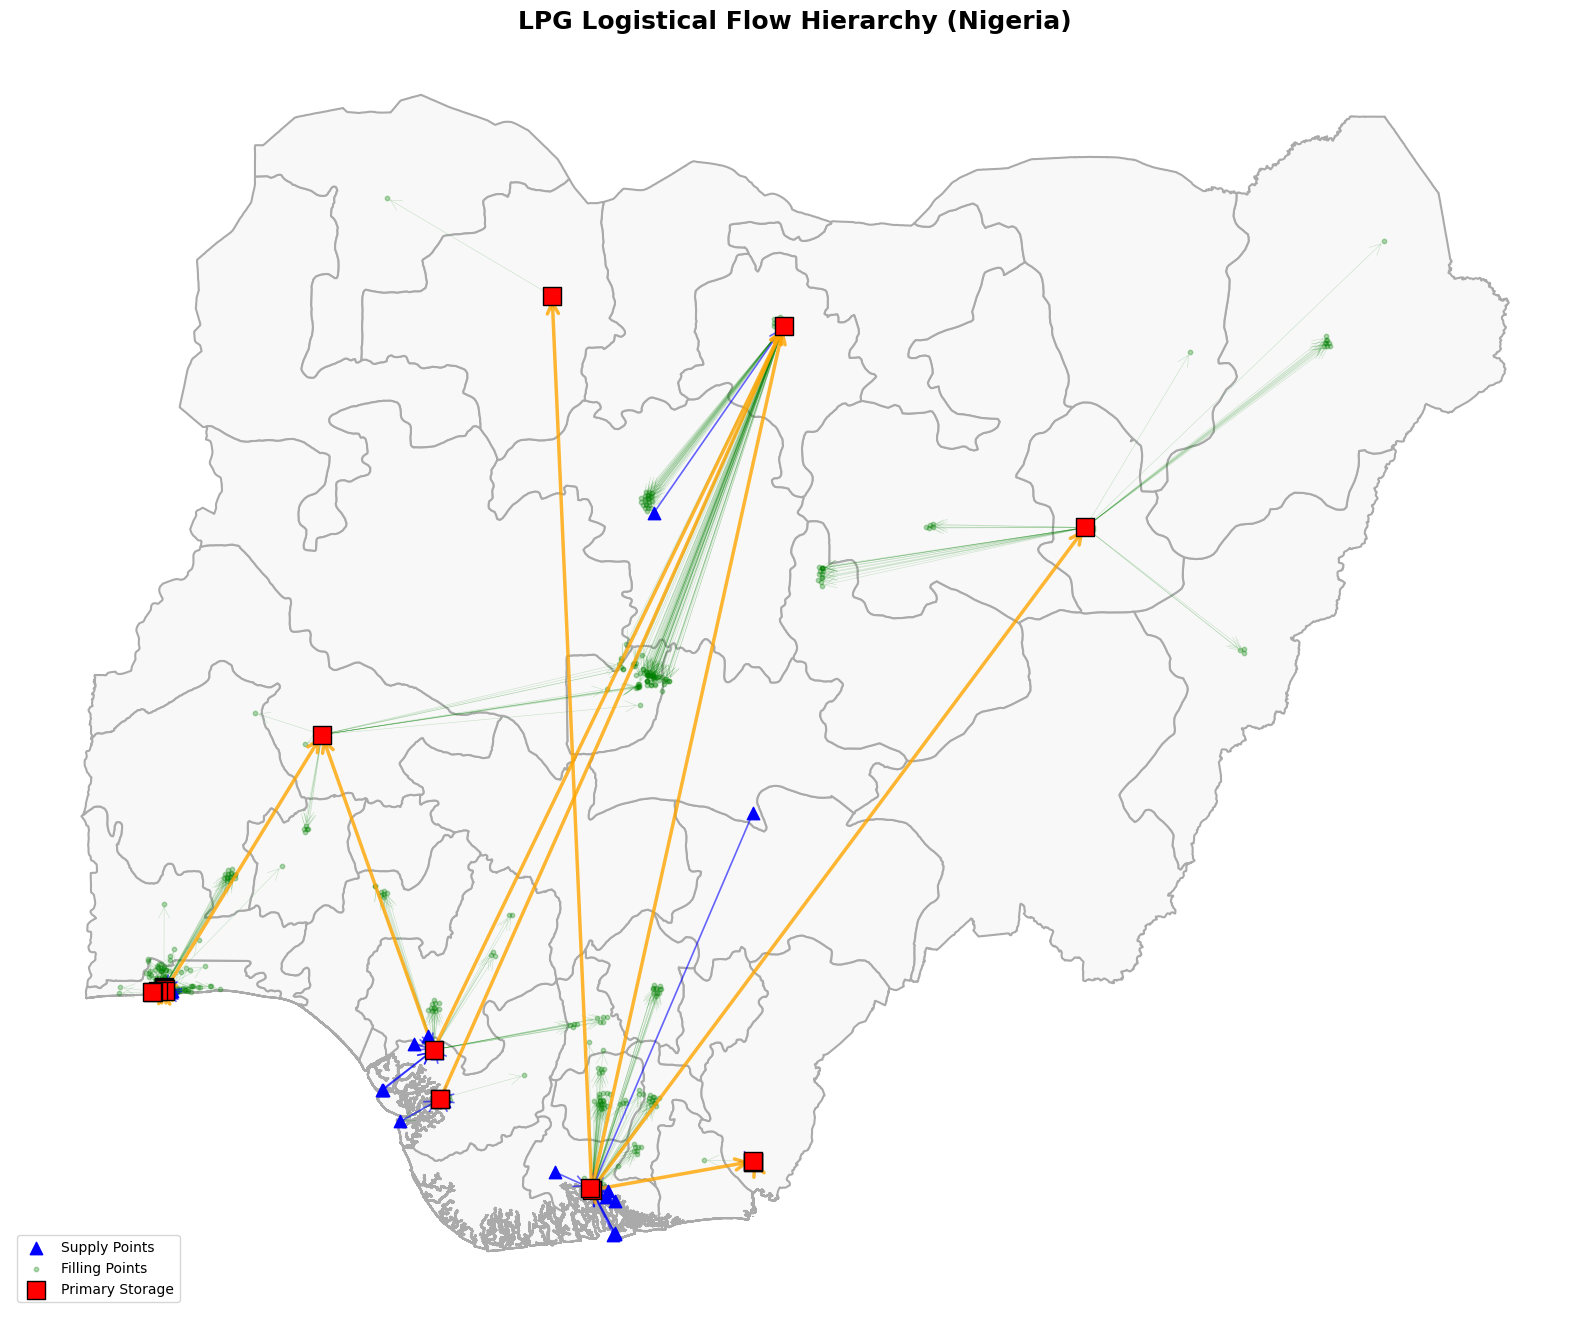

In [44]:
# Visualization of LPG supply chain with directional arrows:
# Blue: Source to Storage | Orange: Rebalancing | Green: Storage to Filling

warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS.*')

# 1. Load Data & Align CRS
ps = points['primary_storage'].copy()
if 'filling_points' in points and points['filling_points'] is not None:
    filling = points['filling_points'].copy()
else:
    filling_path = Path("dataset/filling_point_assigned.gpkg")
    filling = gpd.read_file(filling_path)

# Ensure CRS alignment
if filling.crs != ps.crs:
    filling = filling.to_crs(ps.crs)

# 2. Load Nigeria Background
if COUNTRY_BOUNDARIES_PATH.exists():
    country_bg = gpd.read_file(COUNTRY_BOUNDARIES_PATH).to_crs(ps.crs)
else:
    # Fallback: try to load from a world boundaries file or raise a warning
    print("Warning: Country boundaries file not found. Using no background.")
    country_bg = None

# 3. Collect Supply Layers
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
supply_list = []
for lyr in supply_layers:
    gdf = points.get(lyr)
    if gdf is None or gdf.empty:
        continue
    if gdf.crs != ps.crs:
        gdf = gdf.to_crs(ps.crs)
    supply_list.append(gdf)

supply = pd.concat(supply_list, ignore_index=True) if supply_list else gpd.GeoDataFrame()
ps_dict = {row['id_supply']: row.geometry.centroid for _, row in ps.iterrows()}
n_storage = len(ps)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 16))

# Plot Background
if country_bg is not None and not country_bg.empty:
    country_bg.plot(ax=ax, color='#f8f8f8', edgecolor='#aaaaaa', linewidth=1.5, zorder=0)
else:
    ax.set_facecolor('#fafafa')

def draw_arrow(start, end, color, lw, alpha, zorder=2, head_width=0.08):
    """
    Draw a styled arrow between two point geometries on the map.
    Uses annotate for consistent arrowheads and z-order control.
    Skips drawing when either endpoint is missing.
    Designed for readable, thin flow overlays.
    """
    if start is None or end is None:
        return
    ax.annotate("", xy=(end.x, end.y), xytext=(start.x, start.y),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw, 
                                alpha=alpha, shrinkA=2, shrinkB=2, 
                                mutation_scale=20), zorder=zorder)

# 4. Draw Flows as Arrows
# A. Supply -> Primary Storage (Blue)
blue_arrows = 0
for _, row in supply.iterrows():
    # Use nearest_primary_storage_id to link supply to storage
    tid = row.get('nearest_primary_storage_id')
    if tid in ps_dict:
        draw_arrow(row.geometry.centroid, ps_dict[tid], 'blue', 1.2, 0.6)
        blue_arrows += 1

# B. Rebalancing (Orange) - Thicker arrows
orange_arrows = 0
# Try multiple possible locations for allocation_matrix
alloc_matrix = None
if 'allocation_matrix' in globals():
    alloc_matrix = allocation_matrix
elif 'df_alloc' in globals():
    alloc_matrix = df_alloc
elif 'points' in globals() and 'allocation_matrix' in points:
    alloc_matrix = points['allocation_matrix']

if alloc_matrix is not None:
    for i in range(n_storage):
        for j in range(n_storage):
            if i != j and alloc_matrix[i, j] > 0.001:
                draw_arrow(ps.iloc[i].geometry.centroid, ps.iloc[j].geometry.centroid, 
                           'orange', 2.5, 0.8, zorder=3)
                orange_arrows += 1

# C. Primary -> Filling (Green) - Subtle arrows
green_arrows = 0
for _, row in filling.iterrows():
    tid = row.get('nearest_primary_storage_id')
    if tid in ps_dict:
        draw_arrow(ps_dict[tid], row.geometry.centroid, 'green', 0.4, 0.2, zorder=1)
        green_arrows += 1

# 5. Plot Infrastructure Points
if not supply.empty:
    supply.centroid.plot(ax=ax, color='blue', marker='^', markersize=80, label='Supply Points', zorder=4)
filling.centroid.plot(ax=ax, color='green', marker='o', markersize=10, alpha=0.3, label='Filling Points', zorder=1)
ps.centroid.plot(ax=ax, color='red', marker='s', markersize=150, edgecolor='black', label='Primary Storage', zorder=5)

# Formatting
ax.set_title('LPG Logistical Flow Hierarchy (Nigeria)', fontsize=18, fontweight='bold')
ax.axis('off')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower left', frameon=True)

plt.tight_layout()

output_image_path = data_dir / "chart_4.1_flows.png"

plt.savefig(output_image_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Final export of all layers to first_step.gpkg
tool.export_gpkg(points, data_dir, country)

### 4.2. Cost components bar

Available cost columns in filling_points:
  ['cost_source', 'cost_import_sea', 'cost_sts', 'cost_pre_bottling', 'cost_transport_supply_to_primary_storage', 'cost_storage', 'cost_storage_second', 'cost_transport_primary_storage_to_primary_storage', 'cost_transport_primary_storage_to_filling_points', 'cost_total', 'cost_fil_plants']
Charts saved successfully!


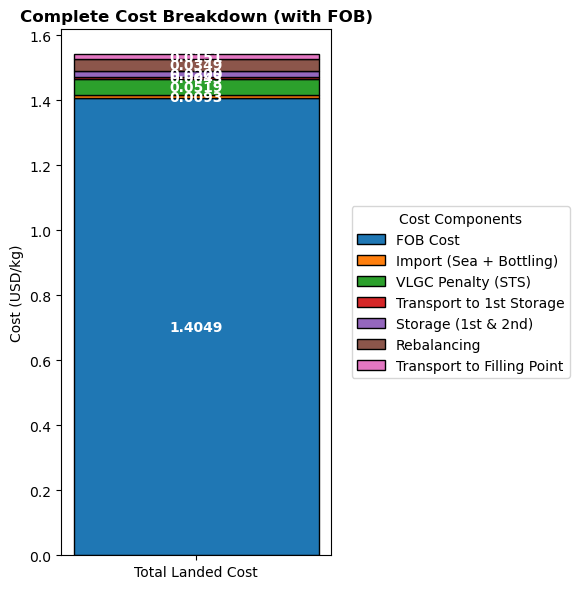

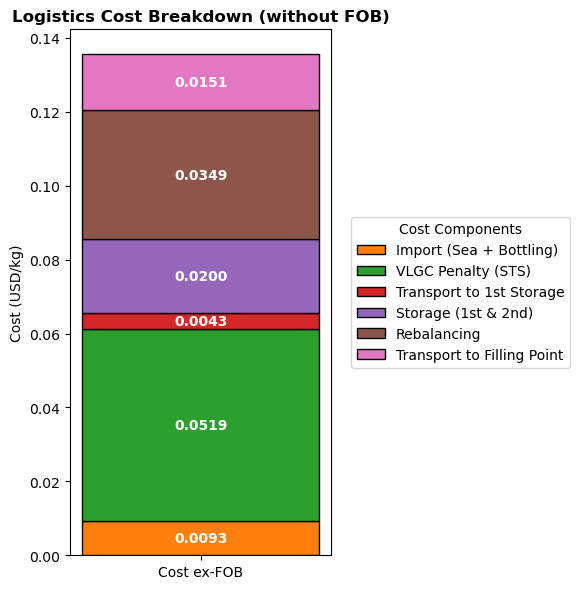

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data
filling = points['filling_points'].copy()

# Helper function to safely get mean from column (avoid KeyError)
def safe_mean(df, col):
    if col in df.columns:
        return df[col].fillna(0).mean()
    return 0.0

# Calculate actual weighted averages directly from the filling points layer
# Grouping similar sub-components for the plot as per your original logic
avg_import_sea = safe_mean(filling, 'cost_import_sea')
avg_pre_bottling = safe_mean(filling, 'cost_pre_bottling')
avg_sts = safe_mean(filling, 'cost_sts')
avg_import_land = safe_mean(filling, 'cost_import_land') + safe_mean(filling, 'cost_border_wait') + safe_mean(filling, 'cost_ferry')
avg_transp1 = safe_mean(filling, 'cost_transport_supply_to_primary_storage')
avg_storage_total = safe_mean(filling, 'cost_storage') + safe_mean(filling, 'cost_storage_second')
avg_rebal = safe_mean(filling, 'cost_transport_primary_storage_to_primary_storage')
avg_transp2 = safe_mean(filling, 'cost_transport_primary_storage_to_filling_points')
avg_fob = safe_mean(filling, 'cost_source')

# Debug: show available columns with 'cost' in name
print("Available cost columns in filling_points:")
cost_cols = [c for c in filling.columns if 'cost' in c.lower()]
print(f"  {cost_cols}")

cost_components = {
    'FOB Cost': avg_fob,
    'Import (Sea + Bottling)': avg_import_sea,
    'Import (Land + Border)': avg_import_land,
    'VLGC Penalty (STS)': avg_sts,
    'Transport to 1st Storage': avg_transp1,
    'Storage (1st & 2nd)': avg_storage_total,
    'Rebalancing': avg_rebal,
    'Transport to Filling Point': avg_transp2
}

# Remove zero-value components
cost_components = {k: v for k, v in cost_components.items() if v > 0}

# 2. Detailed breakdown
"""
avg_dist_transp = filling['tank_distance'].fillna(0).mean()
avg_time_transp = filling['tank_traveltime'].fillna(0).mean()

effective_load_kg = tanker_capacity_kg * utilization_factor
variable_cost_per_km = 0.635
driver_hourly_cost_usd = (driver_annual_salary_usd * salary_multiplier) / (hours_per_day * days_per_year)
fixed_loading_unloading_hours = 1.0

annual_capital_cost_usd = tanker_overnight_cost_usd * crf(discount_rate, tanker_life_years)
annual_license_cost_usd = license_cost_usd * crf(discount_rate, licence_life_years)

# Using avg_dist_transp for the round trip calculation
avg_round_trip_km = 2.0 * avg_dist_transp
trips_per_year = tanker_annual_km / avg_round_trip_km if avg_round_trip_km > 0 else 1

capex_per_kg = annual_capital_cost_usd / (effective_load_kg * trips_per_year)
license_per_kg = annual_license_cost_usd / (effective_load_kg * trips_per_year)

round_trip_hours = (avg_time_transp * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_distance_km = 2.0 * avg_dist_transp

distance_var_per_kg = (variable_cost_per_km * round_trip_distance_km) / effective_load_kg
driver_per_kg = (driver_hourly_cost_usd * round_trip_hours) / effective_load_kg

transport_components = {
    'Capex (Tanker)': capex_per_kg,
    'License': license_per_kg,
    'Variable (Distance)': distance_var_per_kg,
    'Driver (Time)': driver_per_kg
}

"""

# 3. Plot

colors = plt.cm.tab10.colors
bar_width = 0.2 

# Chart 1: Complete Stacked Bar Chart (Total Cost)
fig1, ax1 = plt.subplots(figsize=(6, 6))
bottom_total = 0
for i, (key, value) in enumerate(cost_components.items()):
    if value > 0:  
        ax1.bar('Total Landed Cost', value, bottom=bottom_total, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        # Centered text inside the block
        ax1.text(0, bottom_total + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_total += value

ax1.set_title('Complete Cost Breakdown (with FOB)', fontweight='bold')
ax1.set_ylabel('Cost (USD/kg)')
ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig1.tight_layout()
out1 = data_dir / "chart_4.2.1_complete_cost.png"
fig1.savefig(out1, dpi=300, bbox_inches='tight')

# Chart 2: Stacked Bar Chart WITHOUT FOB
fig2, ax2 = plt.subplots(figsize=(6, 6))
bottom_ex_fob = 0
for i, (key, value) in enumerate(cost_components.items()):
    if key != 'FOB Cost' and value > 0:  
        ax2.bar('Cost ex-FOB', value, bottom=bottom_ex_fob, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        ax2.text(0, bottom_ex_fob + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        bottom_ex_fob += value

ax2.set_title('Logistics Cost Breakdown (without FOB)', fontweight='bold')
ax2.set_ylabel('Cost (USD/kg)')
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
fig2.tight_layout()
out2 = data_dir / "chart_4.2.2_logistics_cost.png"
fig2.savefig(out2, dpi=300, bbox_inches='tight')

print("Charts saved successfully!")